In [1]:
import elapid
print(elapid.__version__)


1.0.1


In [2]:
dir(elapid)

['BufferedLeaveOneOut',
 'CategoricalTransformer',
 'EnsembleModel',
 'GeographicKFold',
 'HingeTransformer',
 'LinearTransformer',
 'MaxentFeatureTransformer',
 'MaxentModel',
 'NicheEnvelopeModel',
 'ProductTransformer',
 'QuadraticTransformer',
 'ThresholdTransformer',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'annotate',
 'apply_model_to_rasters',
 'checkerboard_split',
 'config',
 'distance_weights',
 'download_sample_data',
 'features',
 'geo',
 'load_object',
 'load_sample_data',
 'models',
 'nearest_point_distance',
 'normalize_sample_probabilities',
 'sample_bias_file',
 'sample_geoseries',
 'sample_raster',
 'sample_vector',
 'save_object',
 'stack_geodataframes',
 'stats',
 'train_test_split',
 'types',
 'utils',
 'xy_to_geoseries',
 'zonal_stats']

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from elapid import MaxentModel
from sklearn import metrics
from sklearn.model_selection import train_test_split
import warnings
import rasterio
import os

# Load the data
data = pd.read_csv('src/data/trajectories_cleaned.csv')
bg_data = pd.read_csv('src/data/backgound_points.csv')

base_path = "src/data/raster_201401"
# Load raster
raster_names = [
    "2014_01_jplMURSST41_resampled.tif",
    "2014_01_NESDIS_VHNSQ_chla_resampled.tif",
    "cmems_obs-wind_glo_phy_my_l4_P1M_201401_eastward_stress.tif",
    "cmems_obs-wind_glo_phy_my_l4_P1M_201401_northward_stress.tif",
    "cmems_obs-wind_glo_phy_my_l4_P1M_201401_eastward_wind.tif",
    "cmems_obs-wind_glo_phy_my_l4_P1M_201401_northward_wind.tif"
]
rasters = [os.path.join(base_path, raster) for raster in raster_names]

# Generar etiquetas a partir de los nombres de archivos raster
labels = ["b1", "b2", "b3", "b4", "b5", "b6"]

print("Rutas completas de rasters:", rasters)
print("Etiquetas:", labels)

# preferences
%matplotlib inline
mpl.style.use('ggplot')
warnings.filterwarnings("ignore")


Rutas completas de rasters: ['src/data/raster_201401/2014_01_jplMURSST41_resampled.tif', 'src/data/raster_201401/2014_01_NESDIS_VHNSQ_chla_resampled.tif', 'src/data/raster_201401/cmems_obs-wind_glo_phy_my_l4_P1M_201401_eastward_stress.tif', 'src/data/raster_201401/cmems_obs-wind_glo_phy_my_l4_P1M_201401_northward_stress.tif', 'src/data/raster_201401/cmems_obs-wind_glo_phy_my_l4_P1M_201401_eastward_wind.tif', 'src/data/raster_201401/cmems_obs-wind_glo_phy_my_l4_P1M_201401_northward_wind.tif']
Etiquetas: ['b1', 'b2', 'b3', 'b4', 'b5', 'b6']


In [4]:
presence =  gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['longitude'], data['latitude']))
background = gpd.GeoDataFrame(bg_data, geometry=gpd.points_from_xy(bg_data['longitude'], bg_data['latitude']))

print(presence.head())
print(background.head())

           scientific_name   longitude   latitude    name  year  month  \
0  Phoebastria immutabilis -118.327013  29.110365  LAAL01  2014      1   
1  Phoebastria immutabilis -118.327008  29.110315  LAAL01  2014      1   
2  Phoebastria immutabilis -118.327022  29.110340  LAAL01  2014      1   
3  Phoebastria immutabilis -118.327045  29.110412  LAAL01  2014      1   
4  Phoebastria immutabilis -118.326942  29.110427  LAAL01  2014      1   

                      geometry  
0  POINT (-118.32701 29.11037)  
1  POINT (-118.32701 29.11031)  
2  POINT (-118.32702 29.11034)  
3  POINT (-118.32704 29.11041)  
4  POINT (-118.32694 29.11043)  
    longitude   latitude  rand_point_id  class  area_exten  \
0 -145.672040  13.548375              0      0  background   
1 -131.554414  25.889406              1      0  background   
2 -156.454840  47.053826              2      0  background   
3 -142.677073  16.932239              3      0  background   
4 -148.790676  35.224533              4      0 

In [5]:
# merge datasets and read the covariates at each point location

# merge datasets and read the covariates at each point location
merged = elapid.stack_geodataframes(presence, background, add_class_label=True)
print(merged.head())

print("CRS inicial:", merged.crs)

# Si el CRS es None, debes asignar un CRS adecuado
if merged.crs is None:
    # Define el CRS, por ejemplo, EPSG:4326 (WGS84)
    merged.set_crs(epsg=4326, inplace=True)

print("CRS después de la asignación:", merged.crs)

#merged.to_csv('src/data/merged.csv', index=False)


    longitude   latitude                     geometry  class
0 -118.327013  29.110365  POINT (-118.32701 29.11037)      1
1 -118.327008  29.110315  POINT (-118.32701 29.11031)      1
2 -118.327022  29.110340  POINT (-118.32702 29.11034)      1
3 -118.327045  29.110412  POINT (-118.32704 29.11041)      1
4 -118.326942  29.110427  POINT (-118.32694 29.11043)      1
CRS inicial: None
CRS después de la asignación: EPSG:4326


In [6]:
annotated = elapid.annotate(merged, rasters, drop_na=True, quiet=True)
print(annotated.head())

    longitude   latitude                     geometry  class       b1  \
0 -118.291443  28.884033  POINT (-118.29144 28.88403)      1  17.6467   
1 -118.291348  28.883963  POINT (-118.29135 28.88396)      1  17.6467   
2 -118.291477  28.883865  POINT (-118.29148 28.88387)      1  17.6467   
3 -118.291502  28.883898  POINT (-118.29150 28.88390)      1  17.6467   
4 -118.291407  28.883807  POINT (-118.29141 28.88381)      1  17.6467   

         b2   b3   b4     b5     b6  
0  0.135999  1.0 -4.0  156.0 -432.0  
1  0.135999  1.0 -4.0  156.0 -432.0  
2  0.135999  1.0 -4.0  156.0 -432.0  
3  0.135999  1.0 -4.0  156.0 -432.0  
4  0.135999  1.0 -4.0  156.0 -432.0  


In [7]:
# split the x/y data
x = annotated.drop(columns=['class', 'geometry', 'longitude', 'latitude'])
y = annotated['class']

# train the model
model = elapid.MaxentModel(transform='cloglog', beta_multiplier=2.0)
model.fit(x, y)

# evaluate training performance
ypred = model.predict(x)
auc = metrics.roc_auc_score(y, ypred)
print(f"Training AUC score: {auc:0.3f}")

# save the fitted model to disk
elapid.save_object(model, 'demo-maxent-model.ela')

model = elapid.load_object('demo-maxent-model.ela')

Training AUC score: 0.996


In [8]:
print(model.get_params())
print(model.class_weights)
print(model.transform)


{'beta_categorical': 1.0, 'beta_hinge': 1.0, 'beta_lqp': 1.0, 'beta_multiplier': 2.0, 'beta_threshold': 1.0, 'clamp': True, 'class_weights': 100, 'convergence_tolerance': 2e-06, 'feature_types': ['linear', 'hinge', 'product'], 'n_cpus': 16, 'n_hinge_features': 10, 'n_lambdas': 100, 'n_threshold_features': 10, 'scorer': 'roc_auc', 'tau': 0.5, 'transform': 'cloglog', 'use_lambdas': 'best', 'use_sklearn': True}
100
cloglog


        b1        b2   b3   b4     b5     b6
0  17.6467  0.135999  1.0 -4.0  156.0 -432.0
1  17.6467  0.135999  1.0 -4.0  156.0 -432.0
2  17.6467  0.135999  1.0 -4.0  156.0 -432.0
3  17.6467  0.135999  1.0 -4.0  156.0 -432.0
4  17.6467  0.135999  1.0 -4.0  156.0 -432.0
['b1', 'b2', 'b3', 'b4', 'b5', 'b6']


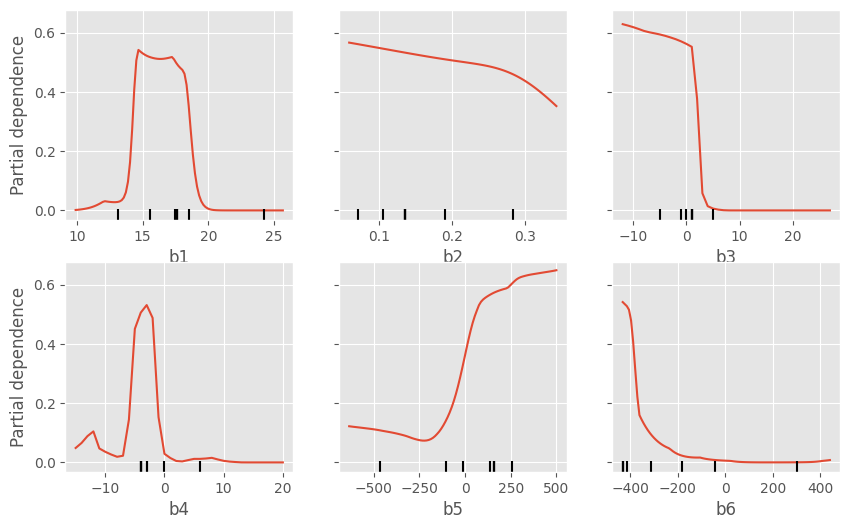

In [9]:
from sklearn.inspection import PartialDependenceDisplay
# partial dependence plots show how model predictions vary across the range of covariates
# Verifica la estructura de 'x' y 'labels'
print(x.head())
print(labels)

#fig, ax = model.partial_dependence_plot(x, labels=labels, dpi=100)

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, x, features=range(len(labels)), feature_names=labels, ax=ax)
plt.show()

In [10]:
# write the model predictions to disk
output_raster = 'demo-maxent-predictions.tif'
elapid.apply_model_to_rasters(model, rasters, output_raster, quiet=True)

# and read into memory
with rasterio.open(output_raster, 'r') as src:
    pred = src.read(1, masked=True)

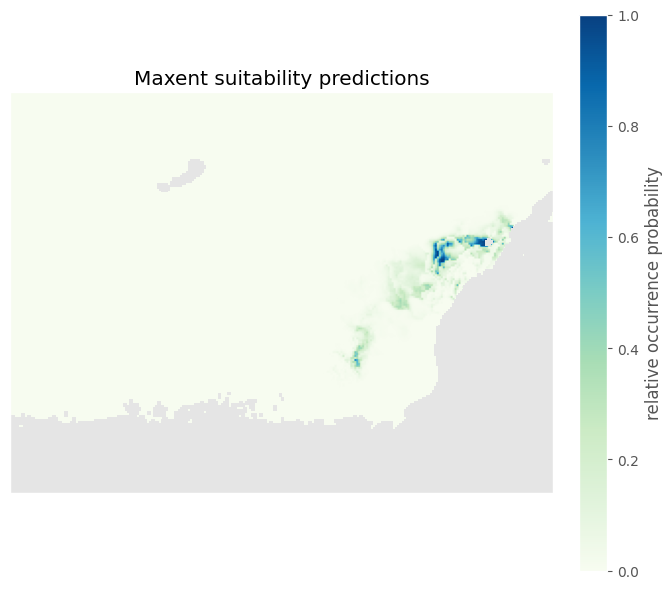

In [23]:
# plot the suitability predictions
fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=100)
plot = ax.imshow(pred, vmin=0, vmax=1, cmap='GnBu')
ax.set_title('Maxent suitability predictions')
ax.set_xticks([])
ax.set_yticks([])
cbar = plt.colorbar(plot, ax=ax, label="relative occurrence probability", pad=0.04)
plt.tight_layout()